In [4]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import pyFBS

from scipy import sparse
from xarray import DataArray
from scipy.sparse.linalg import eigsh
import numpy as np

import pyvista as pv
import pyansys

from pyFBS.utility import *


In [6]:
receiver = "../data/AM_automotive_testbench/STL/receiver.stl"


In [7]:
stl = r"../data/lab_testbench/STL/AB.stl"
xlsx = r"../data/lab_testbench/Measurements/AM_Measurements.xlsx"

full_file = r'..\data\lab_testbench\FEM\AB\file.full'
ress_file = r'..\data\lab_testbench\FEM\AB\file.rst'

In [8]:
MK = pyFBS.MK_model(ress_file,full_file,no_modes = 200)
MK.mesh.points *= 1000

In [9]:
view3D = pyFBS.display.view3D(show_origin= True)

In [10]:
#view3D = pyFBS.display.view3D()
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = 0.2)

In [60]:
view3D.plot.add_mesh(MK.mesh, scalars = np.ones(MK.mesh.points.shape[0]),show_scalar_bar = False,name = "mesh",cmap = "coolwarm",show_edges = True)

(vtkRenderingOpenGL2Python.vtkOpenGLActor)000002BC9290CE28

In [61]:
pts = MK.mesh.points.copy()

In [13]:
view3D.take_gif = False

In [71]:
# Priprava animacije oblike
select_mode = 10   
relative_scale = 30

#kreairanje animacije
_modeshape = np.zeros_like(MK.nodes)
for ref,mode in zip(MK.dof_ref,MK.eig_vec[:,select_mode]):
    _modeshape[ref[0]-1,ref[1]] = mode

#samo priprava vsega za onimacijo v pyFBSu
mode_dict = dict()
mode_dict["animation_pts"] = mode_animation(_modeshape,relative_scale,no_points = 60)
mode_dict["mesh"] = MK.mesh
mode_dict["or_pts"] = pts
mode_dict["scalars"] = True
mode_dict["fps"] = 30

#dodajanje animacije v okno
view3D.add_modeshape(mode_dict,run_animation = True)

In [56]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')
view3D.show_imp(df_imp)
view3D.label_imp(df_imp)
#df_imp

In [17]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
view3D.show_chn(df_chn)
#df_chn

In [48]:
MK.FRF_synth(df_chn,df_imp,modal_damping = 0.003,frf_type = "accelerance")

In [49]:
freq, Y_AB_exp = np.load(r"../data/lab_testbench/Measurements/Y_AB.p",allow_pickle = True)

,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
5,Sensor 2,AM_AB_final,Translation,Acceleration,m/s^2,AM_AB_final,2,100,-0.041679,0.278838,0.0221,0.0,0.0,1.0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
12,Impact 13,AM_AB_final,13,1,Force,N,0.036646,0.364739,0.022246,0.642788,-0.766044,0.0


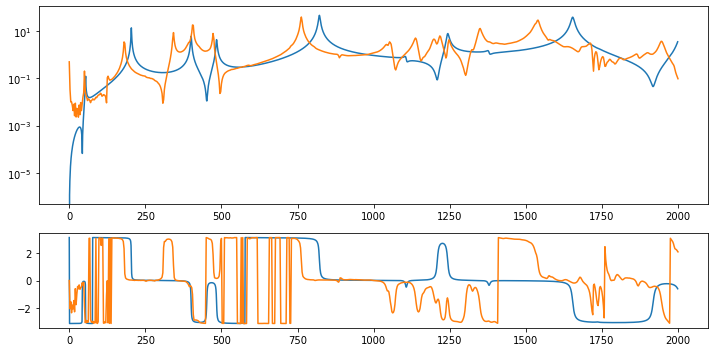

In [74]:
plt.figure(figsize = (12,8))

s1 = 5
s2 = 12

display(df_chn.iloc[[s1]])
display(df_imp.iloc[[s2]])

plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[:,s1,s2]))
plt.semilogy(freq,np.abs(Y_AB_exp[s1,s2]))


plt.subplot(413)
plt.plot(MK.freq,np.angle(MK.FRF[:,s1,s2]))
plt.plot(freq,np.angle(Y_AB_exp[s1,s2]))

